# Log Transformation Comparison

In our earlier analysis, we observed that `total_bill` has a positively skewed distribution and exhibits heteroscedasticity (increasing variance). A common technique to address these issues is applying a **log transformation** to compress the scale and reduce the influence of extreme values.

In this notebook, we compare two OLS models side-by-side:
1. **Regular Model**: Trained on raw `total_bill` → `tip`.
2. **Log Model**: Trained on `log(total_bill)` → `log(tip)`, with predictions converted back to the original scale via `exp()`.

Our goal is to determine whether the log transformation improves our model's performance.

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from utils import ols, mse, rmse, mae, r_squared, adjusted_r_squared

In [133]:
seed = 0
df = sns.load_dataset('tips')
sns.set_theme(style='darkgrid')

### Data Preparation
Split data into Training (80%) and Testing (20%) sets with an intercept column prepended.

In [134]:
from sklearn.model_selection import train_test_split


def produce_training_data(df):
  X = df[['total_bill']]
  y = df['tip'].to_numpy()

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

  assert X_train.shape[0] == y_train.shape[0], "X train's shape does not match the y train's shape"

  X_train = np.concat((np.ones(X_train.shape[0]).reshape(-1, 1), X_train), axis=1)
  X_test = np.concat((np.ones(X_test.shape[0]).reshape(-1, 1), X_test), axis=1)

  return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = produce_training_data(df)

## Model 1: Regular (Raw Data)
Train an OLS regression on the raw `total_bill` and `tip` values as our baseline.

In [135]:
weights_reg = ols(X_train, y_train)
y_pred_reg = X_test @ weights_reg
residuals_reg = y_test - y_pred_reg

## Model 2: Log-Transformed Data
We apply `log()` to both `total_bill` and `tip` before training. This compresses the range and can help linearize relationships that are multiplicative in nature.

In [136]:
X_train_log, X_test_log, y_train_log, y_test_log = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()
X_train_log[:, 1] = np.log(X_train_log[:, 1])
X_test_log[:, 1] = np.log(X_test_log[:, 1])
y_train_log = np.log(y_train_log)

### Train Log Model & Compare Metrics
Train the model in log-space and convert predictions back to the original scale using `exp()`, so the metrics are directly comparable with the regular model.

In [137]:
weights_log = ols(X_train_log, y_train_log)
y_pred_log = X_test_log @ weights_log
y_pred_log = np.exp(y_pred_log)

residuals_log = y_test_log - y_pred_log

In [138]:
pd.DataFrame([
  {
  "MSE": mse(y_test, y_pred_reg),
  "RMSE": rmse(y_test, y_pred_reg), 
  "MAE": mae(y_test, y_pred_reg), 
  "R2": r_squared(y_test, y_pred_reg), 
  "Adjusted_R2": adjusted_r_squared(y_test, y_pred_reg, X_test.shape[1] - 1),
  "model": 'Regular'
  },
  {
  "MSE": mse(y_test_log, y_pred_log),
  "RMSE": rmse(y_test_log, y_pred_log), 
  "MAE": mae(y_test_log, y_pred_log), 
  "R2": r_squared(y_test_log, y_pred_log), 
  "Adjusted_R2": adjusted_r_squared(y_test_log, y_pred_log, X_test_log.shape[1] - 1),
  "model": 'Log'
  }
])

,MSE,RMSE,MAE,R2,Adjusted_R2,model
0,0.821309,0.906261,0.656407,0.590690,0.581981,Regular
1,0.987918,0.993941,0.691526,0.507658,0.497182,Log


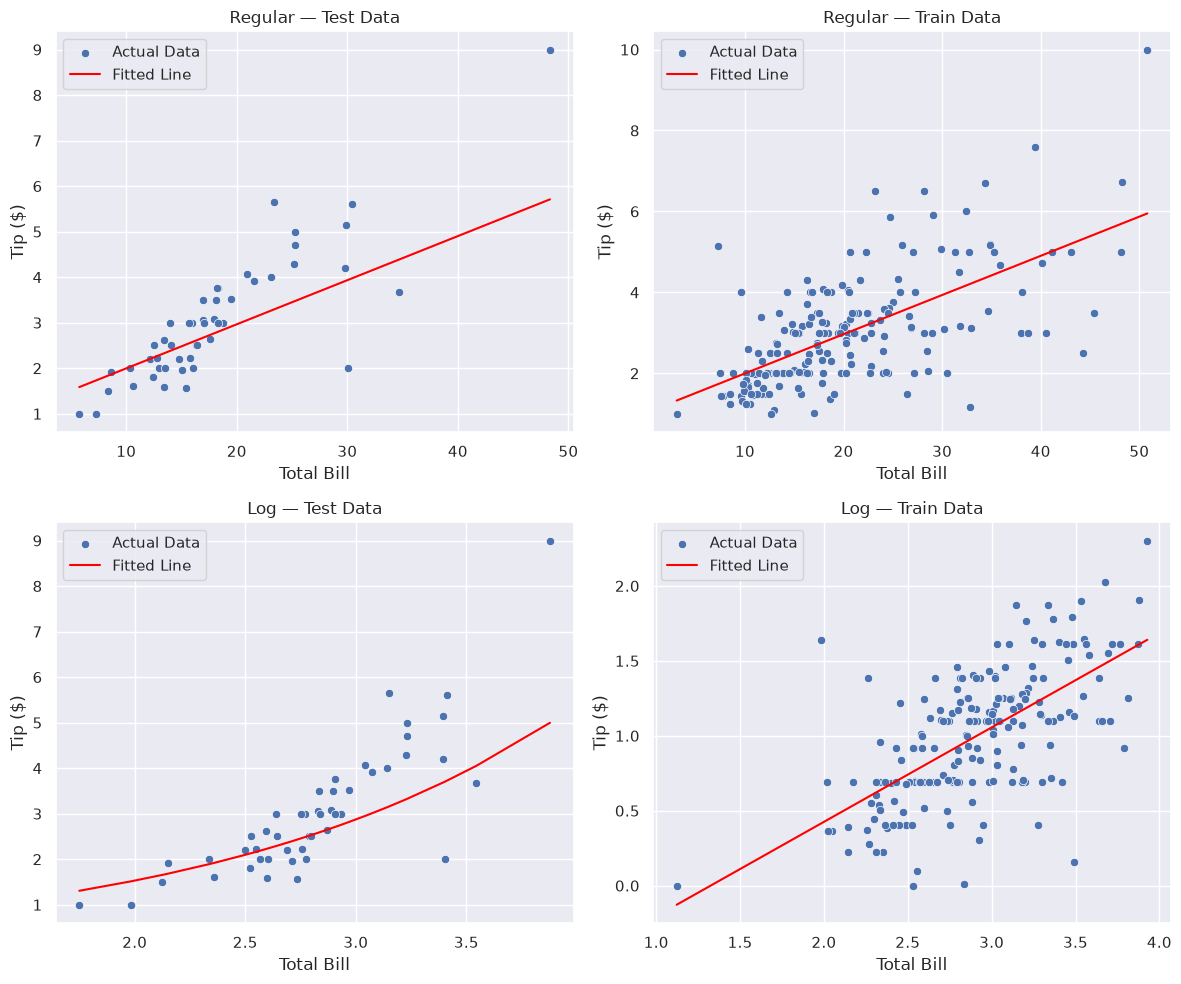

In [139]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Regular Model
sns.scatterplot(x=X_test[:, 1], y=y_test, label='Actual Data', ax=ax1)
sns.lineplot(x=X_test[:, 1], y=y_pred_reg, color='red', label='Fitted Line', ax=ax1)
ax1.set(title='Regular — Test Data', xlabel='Total Bill', ylabel='Tip ($)')

sns.scatterplot(x=X_train[:, 1], y=y_train, label='Actual Data', ax=ax2)
sns.lineplot(x=X_train[:, 1], y=X_train @ weights_reg, color='red', label='Fitted Line', ax=ax2)
ax2.set(title='Regular — Train Data', xlabel='Total Bill', ylabel='Tip ($)')

# Log Model
sns.scatterplot(x=X_test_log[:, 1], y=y_test_log, label='Actual Data', ax=ax3)
sns.lineplot(x=X_test_log[:, 1], y=y_pred_log, color='red', label='Fitted Line', ax=ax3)
ax3.set(title='Log — Test Data', xlabel='Total Bill', ylabel='Tip ($)')

sns.scatterplot(x=X_train_log[:, 1], y=y_train_log, label='Actual Data', ax=ax4)
sns.lineplot(x=X_train_log[:, 1], y=X_train_log @ weights_log, color='red', label='Fitted Line', ax=ax4)
ax4.set(title='Log — Train Data', xlabel='Total Bill', ylabel='Tip ($)')

fig.tight_layout()

Text(0.5, 1.0, 'Log')

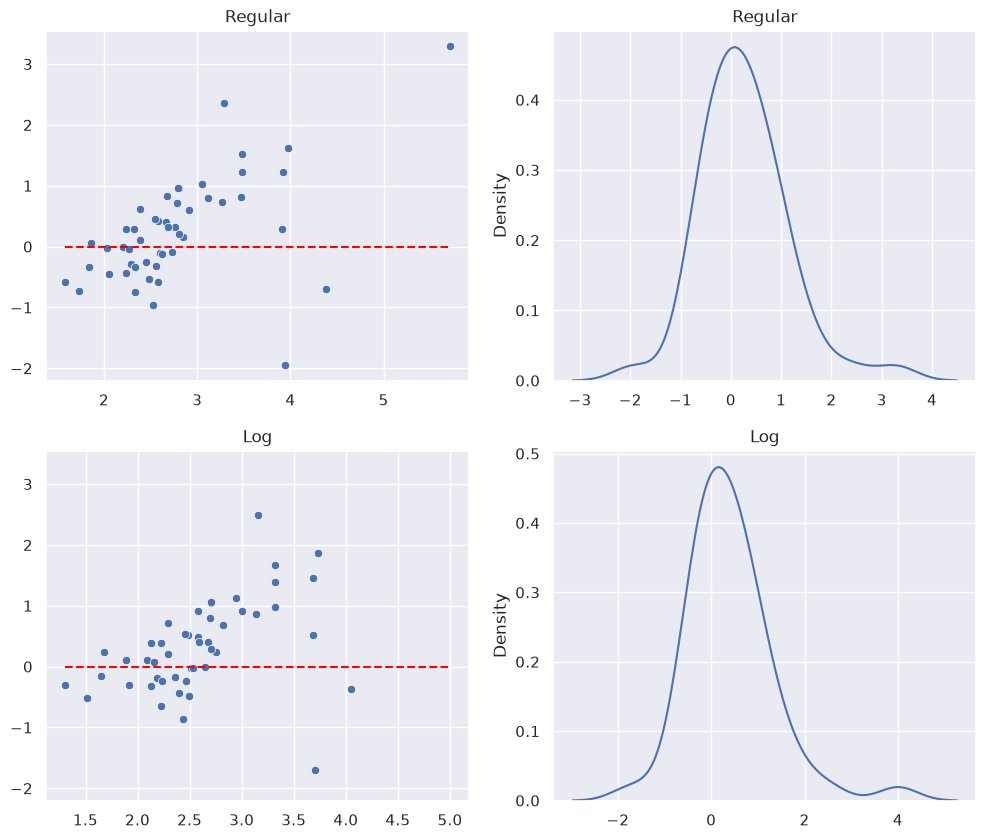

In [140]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(x=y_pred_reg, y=residuals_reg, ax=ax1)
ax1.hlines(y=0, xmin=y_pred_reg.min(), xmax=y_pred_reg.max(), colors='red', linestyle='--')
sns.kdeplot(x=residuals_reg, ax=ax2)
ax1.set_title('Regular')
ax2.set_title('Regular')

sns.scatterplot(x=y_pred_log, y=residuals_log, ax=ax3)
ax3.hlines(y=0, xmin=y_pred_log.min(), xmax=y_pred_log.max(), colors='red', linestyle='--')
ax3.set_ylim(ax1.get_ylim())
sns.kdeplot(x=residuals_log, ax=ax4)
ax3.set_title('Log')
ax4.set_title('Log')

### Observations
- **Regular Model**: The residuals are fairly evenly spread above and below the baseline (0), with no systematic over- or under-estimation. The density plot shows a reasonable bell-shaped curve centered near zero.
- **Log Model**: The residuals show a similar spread, but the density plot reveals a slightly different shape due to the back-transformation from log space to the original scale.
- Neither model shows a dramatic advantage in residual behavior at this stage.

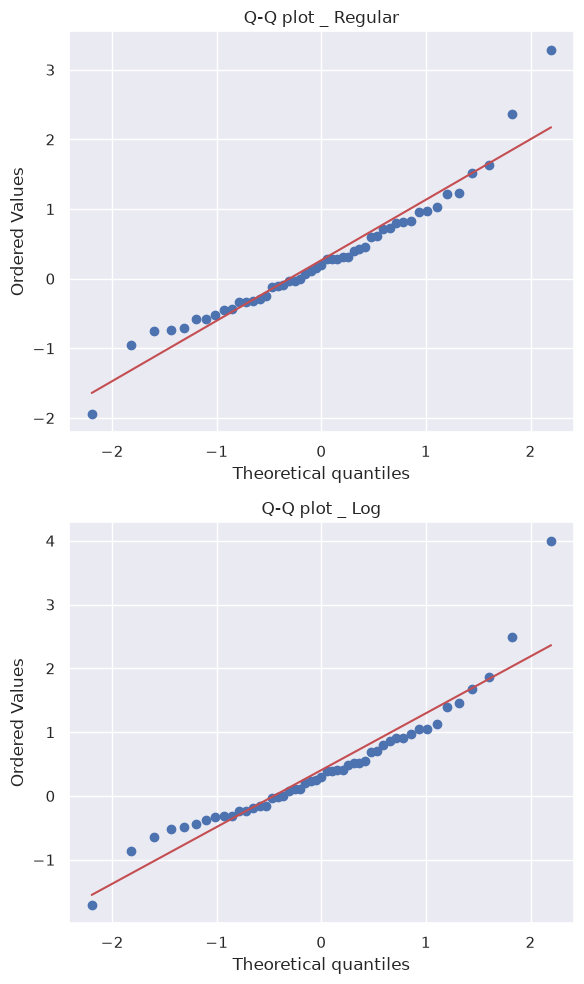

In [141]:
import scipy

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 10))

scipy.stats.probplot(residuals_reg.reshape(-1), plot=ax1, fit=True, dist="norm")
ax1.set_title('Q-Q plot _ Regular')

scipy.stats.probplot(residuals_log.reshape(-1), plot=ax2, fit=True, dist="norm")
ax2.set_title('Q-Q plot _ Log')

fig.tight_layout()
plt.show()

### Observations
- Both Q-Q plots show that the residuals track the theoretical normal line well through the middle quantiles, with deviations at the tails due to outliers.
- The log transformation does not provide a meaningful improvement in the normality of residuals.

## Conclusion
The log transformation was a reasonable experiment given the positive skew and heteroscedasticity in our data. However, comparing the two models side-by-side shows that:

- The **Regular model outperforms** the Log model across all key metrics (lower error and higher $R^2$).
- The residual diagnostics and Q-Q plots are comparable, with neither model showing a clear advantage.

This tells us that the relationship between `total_bill` and `tip` is already well-captured by a simple linear function on the raw data. The log transformation introduces unnecessary non-linearity that hurts rather than helps the fit.

**Decision**: We will proceed with the **regular (untransformed) model** for our final training in the next notebook.